In [1]:
import os
import sys
import joblib
import numpy as np
import torch
from sklearn.metrics import (
    precision_recall_curve,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

MODEL_PATH = "../saved_model/ae_model.pt"
SCALER_PATH = "../saved_model/scaler.joblib"
CTX_SCALER_PATH = "../saved_model/ctx_scaler.joblib"
META_PATH = "../saved_model/detector_meta.joblib"

X_PATH = "../data/processed/X_all.npy"
C_PATH = "../data/processed/C_all.npy"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# import model.py from parent folder
sys.path.append(os.path.abspath(".."))
from src.model import FiLMAutoencoder

Device: cuda


In [2]:
ckpt = torch.load(MODEL_PATH, map_location=device)

model = FiLMAutoencoder(
    window_size=ckpt["window_size"],
    n_features=ckpt["n_features"],
    context_dim=ckpt["context_dim"],
    units=ckpt["units"],
    latent=ckpt["latent"],
).to(device)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Model loaded ✅")
print("window_size:", ckpt["window_size"])
print("n_features :", ckpt["n_features"])
print("context_dim:", ckpt["context_dim"])

Model loaded ✅
window_size: 24
n_features : 8
context_dim: 5


In [3]:
scaler = joblib.load(SCALER_PATH)
ctx_scaler = joblib.load(CTX_SCALER_PATH)
detector_meta = joblib.load(META_PATH)

print("Scaler loaded ✅")
print("Context scaler loaded ✅")
print("Detector meta:", detector_meta)

Scaler loaded ✅
Context scaler loaded ✅
Detector meta: {'topk': 19, 'threshold': 232.83941650390625, 'window_size': 24, 'n_features': 8, 'context_dim': 5}


In [4]:
X = np.load(X_PATH, allow_pickle=False)
C = np.load(C_PATH, allow_pickle=False)

print("Raw loaded:")
print("X:", X.shape, X.dtype)
print("C:", C.shape, C.dtype)

assert X.ndim == 3, f"X should be 3D (N,T,F). Got {X.ndim}D"
assert C.ndim == 2, f"C should be 2D (N,context_dim). Got {C.ndim}D"
assert len(X) == len(C), f"X and C must have same N. Got {len(X)} vs {len(C)}"

N_CLEAN = min(5000, len(X))
X_clean = X[:N_CLEAN].copy()
C_clean = C[:N_CLEAN].copy()

print("Subset ready ✅")
print("X_clean:", X_clean.shape)
print("C_clean:", C_clean.shape)

Raw loaded:
X: (772049, 24, 8) float32
C: (772049, 5) float32
Subset ready ✅
X_clean: (5000, 24, 8)
C_clean: (5000, 5)


In [5]:
if np.isnan(X_clean).mean() > 0:
    print("NaNs found in X_clean -> filling with 0")
    X_clean = np.nan_to_num(X_clean, nan=0.0, posinf=0.0, neginf=0.0)

def apply_scaler(sc, X_in):
    N, T, F = X_in.shape
    X2 = sc.transform(X_in.reshape(N * T, F))
    return X2.reshape(N, T, F).astype(np.float32)

# X_clean already comes after log1p preprocessing from notebook 01
X_clean = apply_scaler(scaler, X_clean)
C_clean = ctx_scaler.transform(C_clean).astype(np.float32)

print("Scaling done ✅")
print("X_clean:", X_clean.shape, X_clean.dtype)
print("C_clean:", C_clean.shape, C_clean.dtype)

Scaling done ✅
X_clean: (5000, 24, 8) float32
C_clean: (5000, 5) float32


In [6]:
def inject_anomalies(
    x,
    anomaly_ratio=0.08,
    seed=42,
    spike_mag=6.0,
    noise_std=0.8,
    seg_len=12,
    n_affect=2
):
    rng = np.random.default_rng(seed)
    x_anom = x.copy()
    n, T, F = x_anom.shape

    k = int(n * anomaly_ratio)
    idx = rng.choice(n, k, replace=False)

    y = np.zeros(n, dtype=np.int32)
    y[idx] = 1

    for i in idx:
        seg = min(seg_len, T)
        t0 = int(rng.integers(0, max(1, T - seg + 1)))
        feats = rng.choice(F, size=min(n_affect, F), replace=False)
        t_idx = np.arange(t0, t0 + seg)

        mode = rng.choice(["spike", "drop", "noise"])
        if mode == "spike":
            x_anom[i][np.ix_(t_idx, feats)] += spike_mag
        elif mode == "drop":
            x_anom[i][np.ix_(t_idx, feats)] -= spike_mag
        else:
            x_anom[i][np.ix_(t_idx, feats)] += rng.normal(
                0, noise_std, size=(len(t_idx), len(feats))
            )

    return x_anom, y

In [7]:
X_test, y_true = inject_anomalies(
    X_clean,
    anomaly_ratio=0.08,
    seed=42
)

print("Synthetic test ready ✅")
print("X_test:", X_test.shape)
print("y_true positives:", int(y_true.sum()))

Synthetic test ready ✅
X_test: (5000, 24, 8)
y_true positives: 400


In [8]:
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
C_clean_t = torch.tensor(C_clean, dtype=torch.float32).to(device)

with torch.no_grad():
    X_test_pred = model(X_test_t, C_clean_t).cpu().numpy()

print("Inference done ✅")
print("Pred shape:", X_test_pred.shape)

Inference done ✅
Pred shape: (5000, 24, 8)


In [9]:
def topk_score(x_true, x_pred, k):
    err = (x_true - x_pred) ** 2
    flat = err.reshape(len(err), -1)
    k = min(k, flat.shape[1])
    part = np.partition(flat, -k, axis=1)[:, -k:]
    return np.mean(part, axis=1)

In [10]:
WINDOW_SIZE = X_test.shape[1]
N_FEATURES = X_test.shape[2]
TOPK = max(10, int(0.10 * (WINDOW_SIZE * N_FEATURES)))

test_scores = topk_score(X_test, X_test_pred, TOPK)

print("Scores computed ✅")
print("TOPK:", TOPK)
print("min :", float(test_scores.min()))
print("max :", float(test_scores.max()))
print("mean:", float(test_scores.mean()))

Scores computed ✅
TOPK: 19
min : 0.015503475442528725
max : 497.0875244140625
mean: 4.029715061187744


In [11]:
prec, rec, thr = precision_recall_curve(y_true, test_scores)

f1 = 2 * prec * rec / (prec + rec + 1e-12)
best_i = np.argmax(f1)

if len(thr) > 0:
    best_thr = thr[max(0, best_i - 1)]
else:
    best_thr = float(np.percentile(test_scores, 95))

print("Best threshold:", float(best_thr))
print("Best Precision:", float(prec[best_i]))
print("Best Recall   :", float(rec[best_i]))
print("Best F1       :", float(f1[best_i]))

y_hat = (test_scores >= best_thr).astype(int)

p, r, f1_final, _ = precision_recall_fscore_support(
    y_true, y_hat, average="binary", zero_division=0
)
cm = confusion_matrix(y_true, y_hat)

print("\n✅ FINAL RESULTS")
print("Precision:", float(p))
print("Recall   :", float(r))
print("F1       :", float(f1_final))
print("PR-AUC   :", float(average_precision_score(y_true, test_scores)))
print("ROC-AUC  :", float(roc_auc_score(y_true, test_scores)))
print("Confusion Matrix:\n", cm)

Best threshold: 8.206302642822266
Best Precision: 0.52
Best Recall   : 0.65
Best F1       : 0.577777777777284

✅ FINAL RESULTS
Precision: 0.5189620758483033
Recall   : 0.65
F1       : 0.5771365149833518
PR-AUC   : 0.37306618989257395
ROC-AUC  : 0.9108059782608695
Confusion Matrix:
 [[4359  241]
 [ 140  260]]


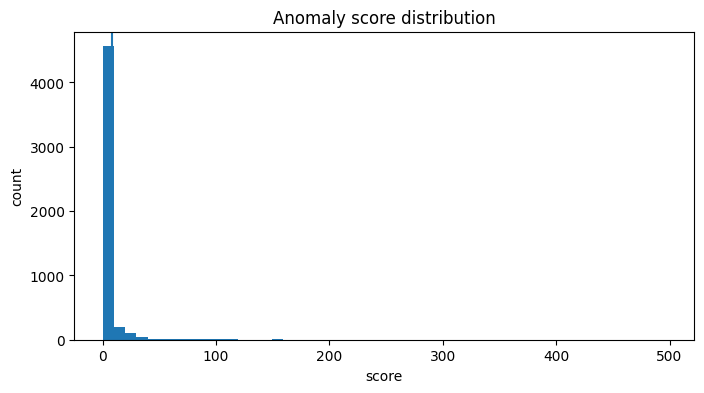

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(test_scores, bins=50)
plt.axvline(best_thr)
plt.title("Anomaly score distribution")
plt.xlabel("score")
plt.ylabel("count")
plt.show()

In [13]:
anom_idx = np.where(y_hat == 1)[0][:20]

print("First predicted anomalies:")
for i in anom_idx:
    print(
        f"idx={i:04d} | score={test_scores[i]:.6f} | "
        f"pred={y_hat[i]} | true={y_true[i]}"
    )

First predicted anomalies:
idx=0026 | score=25.397875 | pred=1 | true=1
idx=0034 | score=8.556183 | pred=1 | true=1
idx=0048 | score=8.696774 | pred=1 | true=1
idx=0094 | score=8.786942 | pred=1 | true=1
idx=0105 | score=26.631296 | pred=1 | true=1
idx=0108 | score=12.522970 | pred=1 | true=1
idx=0114 | score=55.746422 | pred=1 | true=0
idx=0115 | score=82.375031 | pred=1 | true=0
idx=0116 | score=99.308647 | pred=1 | true=0
idx=0117 | score=77.631668 | pred=1 | true=0
idx=0118 | score=75.114227 | pred=1 | true=0
idx=0119 | score=87.447746 | pred=1 | true=0
idx=0120 | score=83.094383 | pred=1 | true=0
idx=0121 | score=80.003433 | pred=1 | true=0
idx=0122 | score=112.271782 | pred=1 | true=0
idx=0123 | score=143.546951 | pred=1 | true=0
idx=0124 | score=95.359062 | pred=1 | true=0
idx=0125 | score=100.788345 | pred=1 | true=0
idx=0126 | score=99.314438 | pred=1 | true=0
idx=0127 | score=91.211807 | pred=1 | true=0
